# Quantum Autoencoder: 10 → 4 Qubits (Angle-Encoded DDoS Features)

Dieses Notebook trainiert einen **Quantum Autoencoder** auf 10‑dimensionale Netzwerk‑Flow‑Features (CICFlowMeter / CICDDoS2019‑Stil), die per **Angle Encoding** ($R_y$, ein Feature pro Qubit) in einen 10‑Qubit‑Produktzustand abgebildet werden.

Das Training erfolgt über den **SWAP‑Test** auf den Trash‑Qubits — der Decoder muss nicht separat gelernt werden, denn er ist nach dem Training $U^\dagger(\theta^*)$.

## Architektur

| Komponente | Anzahl Qubits |
|---|---|
| `num_latent` | 4 |
| `num_trash`  | 6 |
| `num_qubits` (Eingang, ein Feature pro Qubit) | 10 |
| Referenz‑Register | 6 |
| Auxiliary (SWAP‑Test) | 1 |
| **Total Trainings‑Schaltkreis** | **17** |

## Wann der QAE funktioniert

Angle‑Encoded Product States haben 10 unabhängige Winkel. Lossless‑Kompression auf 4 Qubits ist nur möglich, wenn die Daten auf einer **niedrig‑dimensionalen Mannigfaltigkeit** im 10‑dim Parameterraum liegen. Bei DDoS‑Daten ist genau das der Fall: Features sind stark korreliert (hohe Packet‑Rate ↔ viele SYN‑Flags ↔ asymmetrischer Flow), sodass die effektive Dimensionalität klein genug ist.


In [1]:
# Falls noch nicht vorhanden:
# pip install qiskit qiskit-aer matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity, partial_trace
from qiskit.primitives import StatevectorSampler

from scipy.optimize import minimize

np.random.seed(42)


## 1 — Parameter

Layout der Qubits im Trainings‑Schaltkreis:

```
[0 ............... num_latent-1]                 → Latent (bleiben nach Encoder)
[num_latent ...... num_latent+num_trash-1]       → Trash  (sollen → |0⟩)
[num_latent+num_trash ... +2*num_trash-1]        → Referenz |0⟩^num_trash
[num_latent + 2*num_trash]                       → Auxiliary (SWAP-Test)
```


In [ ]:
num_latent  = 3
num_trash   = 2
num_qubits  = num_latent + num_trash       # 10  (Eingang = #features)
ansatz_reps = 5

total_qubits = num_latent + 2 * num_trash + 1  # 17
aux_qubit    = num_latent + 2 * num_trash      # Index des Auxiliary-Qubits

print(f"Eingangs-Qubits (Features):      {num_qubits}")
print(f"Latent-Qubits:                   {num_latent}")
print(f"Trash-Qubits:                    {num_trash}")
print(f"Total Qubits (mit SWAP-Test):    {total_qubits}")


Eingangs-Qubits (Features):      10
Latent-Qubits:                   4
Trash-Qubits:                    6
Total Qubits (mit SWAP-Test):    17


## 2 — Encoder Ansatz

`RealAmplitudes` mit `reps=5` ⇒ $\,n_q \cdot (\text{reps}+1) = 60$ trainierbare Parameter. Linear‑entanglement reicht für 10 Qubits und ist hardware‑freundlich.


/var/folders/20/lcst4q7d7292grcdmdn50f_w0000gn/T/ipykernel_12421/2474737763.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=ansatz_reps)


Anzahl trainierbarer Parameter: 60


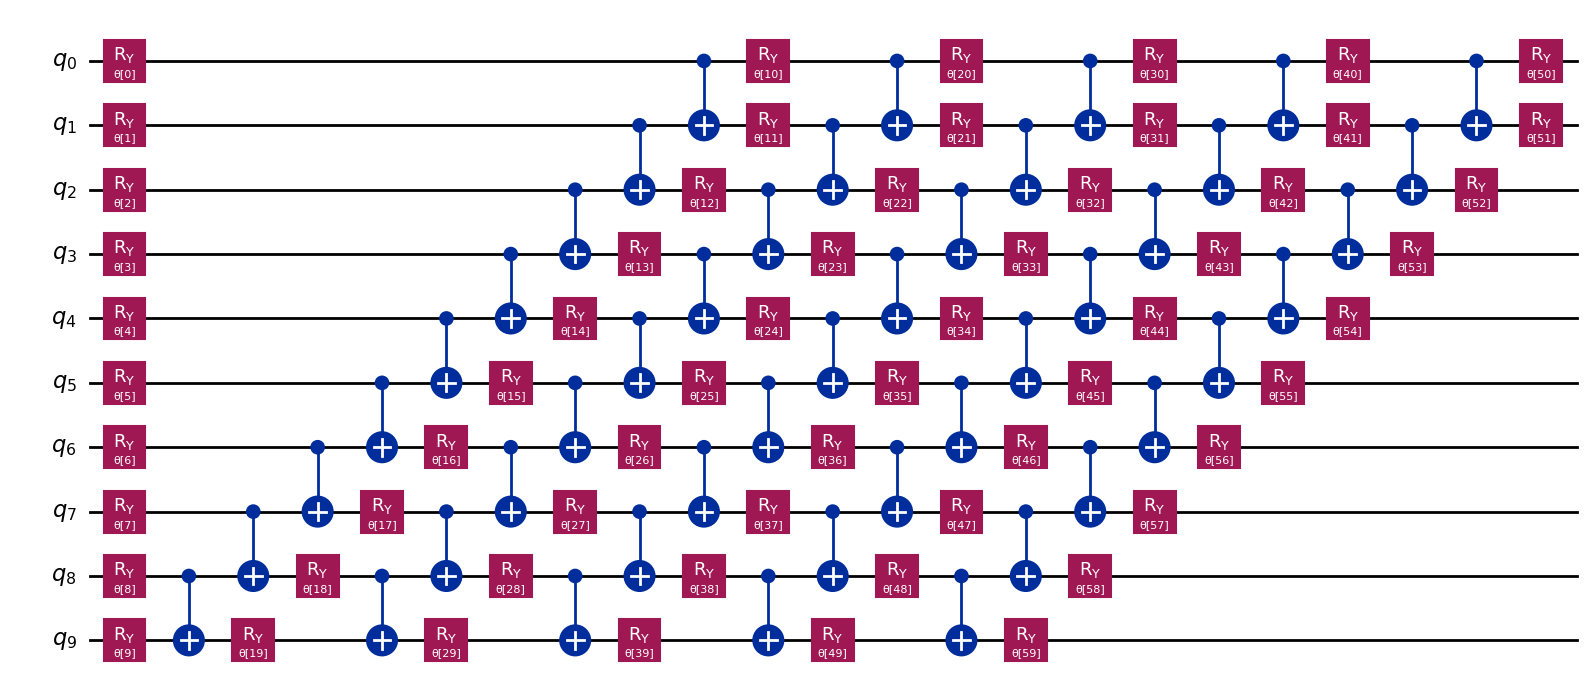

In [3]:
ansatz = RealAmplitudes(num_qubits, reps=ansatz_reps)
print(f"Anzahl trainierbarer Parameter: {ansatz.num_parameters}")
ansatz.decompose().draw("mpl", fold=-1)


## 3 — Trainings‑Schaltkreis mit SWAP‑Test

$P(|0\rangle_{\text{aux}}) = \tfrac{1}{2}(1 + |\langle\psi_{\text{trash}}|0\rangle^{\otimes 6}|^2)$ ⇒ Minimieren von $P(|1\rangle_{\text{aux}})$ maximiert die Fidelität der Trash‑Qubits gegen $|0\rangle^{\otimes 6}$.


Total Qubits:  17
Parameter:     60


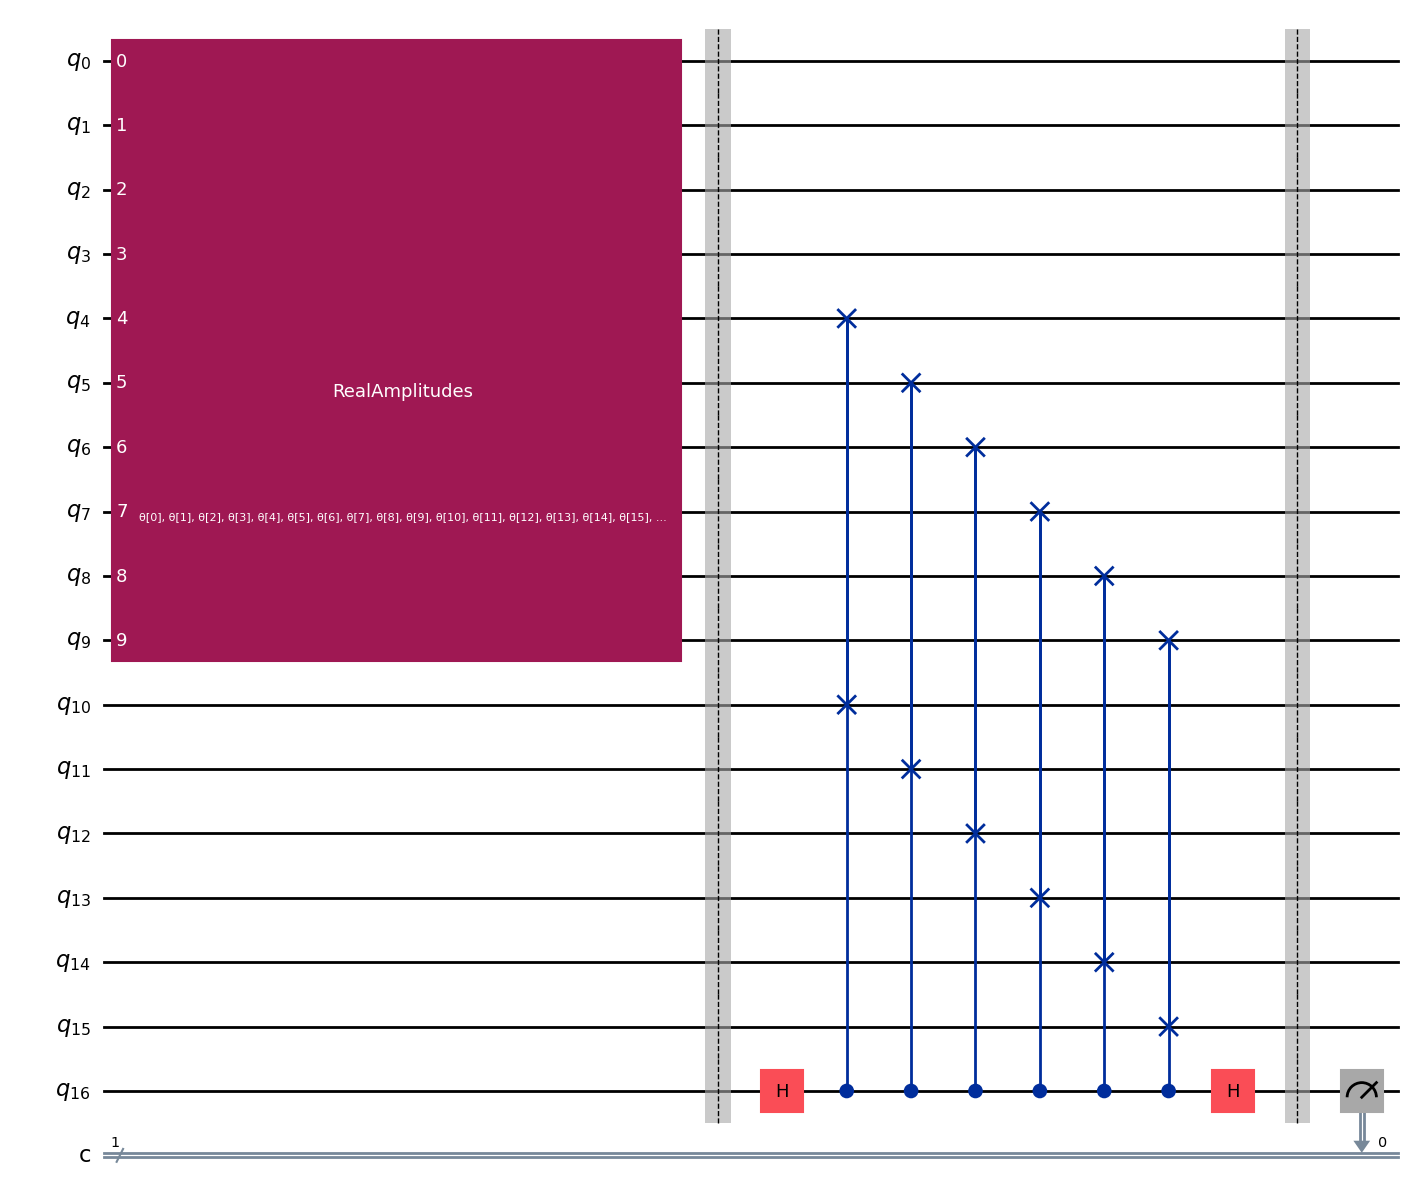

In [4]:
def auto_encoder_circuit(num_latent, num_trash, ansatz):
    """Encoder + SWAP-Test (Trash ↔ Referenzregister)."""
    from qiskit import QuantumRegister, ClassicalRegister
    total = num_latent + 2 * num_trash + 1
    aux   = num_latent + 2 * num_trash

    qr = QuantumRegister(total, "q")
    cr = ClassicalRegister(1, "c")
    qc = QuantumCircuit(qr, cr)

    qc.compose(ansatz, qubits=range(num_latent + num_trash), inplace=True)
    qc.barrier()

    qc.h(aux)
    for i in range(num_trash):
        qc.cswap(aux, num_latent + i, num_latent + num_trash + i)
    qc.h(aux)
    qc.barrier()

    qc.measure(aux, cr[0])
    return qc


ae_circuit = auto_encoder_circuit(num_latent, num_trash, ansatz)
print(f"Total Qubits:  {ae_circuit.num_qubits}")
print(f"Parameter:     {ae_circuit.num_parameters}")
ae_circuit.draw("mpl", fold=-1)


## 4 — Angle Encoding (DDoS Features)

Übernommen aus `angle_encoding_ddos.ipynb`. 10 CICFlowMeter‑Features → Min‑Max‑Skalierung auf $[0, \pi]$ → ein $R_y(\theta_i)$ pro Qubit:

$$R_y(\theta_i)|0\rangle = \cos(\theta_i/2)|0\rangle + \sin(\theta_i/2)|1\rangle.$$


In [ ]:
FEATURE_NAMES = [
    "Flow Duration (us)",
    "Total Fwd Packets",
    "Total Bwd Packets",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean (us)",
    "SYN Flag Count",
    "Packet Length Variance",
]

FEATURE_RANGES = np.array([
    [0.0, 1.2e8],
    [0.0, 1.0e4],
    [0.0, 1.0e4],
    [0.0, 1500.0],
    [0.0, 1500.0],
    [0.0, 1.0e8],
    [0.0, 1.0e6],
    [0.0, 1.0e7],
    [0.0, 100.0],
    [0.0, 5.0e5],
])


def normalize_features(features, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Min-max Skalierung auf [0, angle_max]."""
    features = np.asarray(features, dtype=float)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    norm = (features - fmin) / (fmax - fmin + 1e-12)
    return np.clip(norm, 0.0, 1.0) * angle_max


def denormalize_features(angles, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Inverse: Winkel → physikalische Einheiten."""
    angles = np.where(angles < 0.0, angles + 2.0 * np.pi, angles)
    norm = np.clip(angles / angle_max, 0.0, 1.0)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    return norm * (fmax - fmin) + fmin


def angle_encode(angles, rotation="ry"):
    """Ein Feature pro Qubit, single-qubit Rotation."""
    n = len(angles)
    qc = QuantumCircuit(n, name="AngleEncoding")
    for i, theta in enumerate(angles):
        if rotation == "ry":
            qc.ry(theta, i)
        elif rotation == "rx":
            qc.rx(theta, i)
        elif rotation == "rz":
            qc.h(i)
            qc.rz(theta, i)
        else:
            raise ValueError(f"unsupported rotation: {rotation}")
    return qc


## 5 — Synthetischer Trainingsdatensatz

Zwei Cluster mit realistischer Flow-Charakteristik:

- **Benign:** symmetrische Web-Traffic-Flows, moderate Werte.
- **DDoS (SYN-Flood):** kurz, asymmetrisch, hohe Packet-Rate, viele SYN-Flags.

Ersetze `flows` einfach durch deinen echten CICDDoS2019-Datensatz, sobald verfügbar — der Rest des Notebooks bleibt unverändert.


In [6]:
def generate_synthetic_flows(n_benign=15, n_attack=15, seed=42):
    """Erzeugt 2-Cluster-DDoS-Detection-Datensatz."""
    rng = np.random.default_rng(seed)

    # Benign: moderates Web-Traffic
    benign_center = np.array([
        1.5e7,    # Flow Duration ~15s
        25,       # Fwd Packets
        25,       # Bwd Packets (symmetrisch)
        500.0,    # Fwd Pkt Len Mean
        500.0,    # Bwd Pkt Len Mean
        1.0e4,    # Flow Bytes/s
        1.0e2,    # Flow Packets/s
        5.0e4,    # Flow IAT Mean
        1.0,      # SYN Flag Count
        5.0e4,    # Pkt Len Variance
    ])
    benign_scale = benign_center * 0.4

    # SYN-Flood: kurz, asymmetrisch, schnell, viele SYNs
    attack_center = np.array([
        1.0e5,    # Flow Duration kurz
        5.0e3,    # Fwd Packets viele
        50,       # Bwd Packets wenige (asymmetrisch)
        60.0,     # Fwd Pkt Len Mean klein
        20.0,     # Bwd Pkt Len Mean klein/null
        5.0e7,    # Flow Bytes/s sehr hoch
        5.0e5,    # Flow Packets/s sehr hoch
        1.0e2,    # Flow IAT Mean sehr klein
        80.0,     # SYN Flag Count hoch
        500.0,    # Pkt Len Variance niedrig
    ])
    attack_scale = attack_center * 0.25

    benign = rng.normal(benign_center, benign_scale, size=(n_benign, 10))
    attack = rng.normal(attack_center, attack_scale, size=(n_attack, 10))

    flows  = np.vstack([benign, attack])
    flows  = np.clip(flows, 0.0, None)
    labels = np.array([0]*n_benign + [1]*n_attack)

    return flows, labels


flows, labels = generate_synthetic_flows(n_benign=15, n_attack=15, seed=42)
print(f"Anzahl Flows: {len(flows)}  ({sum(labels==0)} benign, {sum(labels==1)} attack)")

# Normalisieren + State-Preparation-Schaltkreise bauen
training_angles = np.stack([normalize_features(f) for f in flows])
training_states = [angle_encode(a, rotation="ry") for a in training_angles]

print(f"\nWinkel-Range über alle Flows: [{training_angles.min():.3f}, {training_angles.max():.3f}] rad")
print(f"Trainingszustände: {len(training_states)} × {training_states[0].num_qubits} Qubits")


Anzahl Flows: 30  (15 benign, 15 attack)

Winkel-Range über alle Flows: [0.000, 3.142] rad
Trainingszustände: 30 × 10 Qubits


/var/folders/20/lcst4q7d7292grcdmdn50f_w0000gn/T/ipykernel_12421/3810616970.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([training_angles[benign_mask, i] for i in positions],
/var/folders/20/lcst4q7d7292grcdmdn50f_w0000gn/T/ipykernel_12421/3810616970.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([training_angles[attack_mask, i] for i in positions],


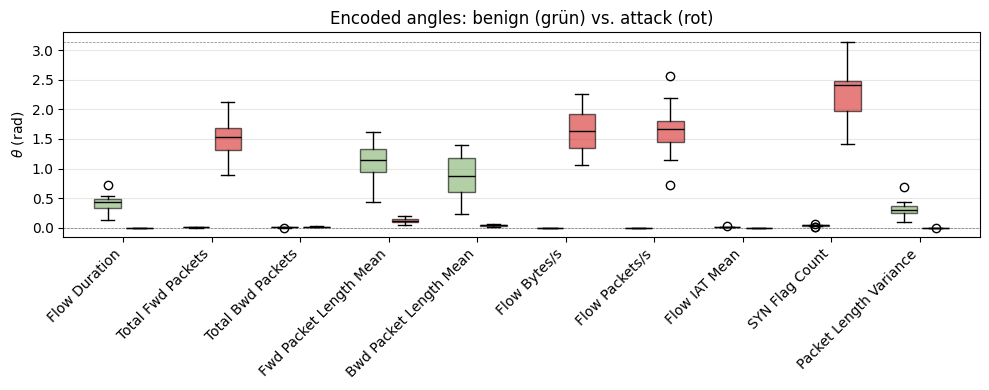

In [7]:
# Quick-Visualization: Verteilung der Winkel pro Feature
fig, ax = plt.subplots(figsize=(10, 4))
positions = range(num_qubits)

benign_mask = labels == 0
attack_mask = labels == 1

ax.boxplot([training_angles[benign_mask, i] for i in positions],
           positions=[p - 0.18 for p in positions], widths=0.3,
           patch_artist=True, boxprops=dict(facecolor="#7fb069", alpha=0.6),
           medianprops=dict(color="black"), labels=[""]*num_qubits)
ax.boxplot([training_angles[attack_mask, i] for i in positions],
           positions=[p + 0.18 for p in positions], widths=0.3,
           patch_artist=True, boxprops=dict(facecolor="#d62828", alpha=0.6),
           medianprops=dict(color="black"), labels=[""]*num_qubits)

ax.set_xticks(positions)
ax.set_xticklabels([n.split("(")[0].strip() for n in FEATURE_NAMES],
                   rotation=45, ha="right")
ax.set_ylabel(r"$\theta$ (rad)")
ax.set_title("Encoded angles: benign (grün) vs. attack (rot)")
ax.axhline(np.pi, color="k", lw=0.5, linestyle="--", alpha=0.5)
ax.axhline(0, color="k", lw=0.5, linestyle="--", alpha=0.5)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 6 — Kostenfunktion

Für jeden Flow im Trainingsset:  State‑Prep (Angle Encoding) + Encoder $U(\theta)$ + SWAP‑Test, dann Mittelwert von $P(|1\rangle_{\text{aux}})$.


In [8]:
def build_full_circuit(state_prep, ae_circuit):
    """State-Prep + Autoencoder-Trainings-Schaltkreis."""
    full = QuantumCircuit(*ae_circuit.qregs, *ae_circuit.cregs)
    full.compose(state_prep, qubits=range(state_prep.num_qubits), inplace=True)
    full.compose(ae_circuit, inplace=True)
    return full


training_circuits = [build_full_circuit(sp, ae_circuit) for sp in training_states]

sampler = StatevectorSampler()
SHOTS = 1024

cost_history = []

def cost_function(params):
    """Mittel von P(|1⟩_aux) über alle Trainings-Flows."""
    param_dict = dict(zip(ansatz.parameters, params))
    bound = [qc.assign_parameters(param_dict) for qc in training_circuits]

    job    = sampler.run(bound, shots=SHOTS)
    result = job.result()

    cost = 0.0
    for pub_result in result:
        counts = pub_result.data.c.get_counts()
        total  = sum(counts.values())
        cost  += counts.get("1", 0) / total
    cost /= len(training_circuits)

    cost_history.append(cost)
    if len(cost_history) % 10 == 0:
        print(f"Iter {len(cost_history):4d}   cost = {cost:.4f}")
    return cost


## 7 — Training

`scipy.optimize.minimize` mit **COBYLA** (gradientenfrei, robust gegen Sampling-Rauschen).

> **Laufzeit:** ~30 Flows × 17 Qubits × ~200 Iterationen → einige Minuten auf Apple Silicon. Für ersten Smoke-Test `maxiter=30` setzen.


In [9]:
initial_params = np.random.uniform(-0.1, 0.1, ansatz.num_parameters)

print(f"Starte Training mit {ansatz.num_parameters} Parametern, {len(training_circuits)} Trainings-Flows...")
print(f"Initiale Kosten: {cost_function(initial_params):.4f}\n")

result = minimize(
    cost_function,
    initial_params,
    method="COBYLA",
    options={"maxiter": 200, "rhobeg": 0.5, "disp": True},
)

optimal_params = result.x
print(f"\nFinale Kosten:                {result.fun:.4f}")
print(f"Implizite mittlere Fidelität: {1 - 2*result.fun:.4f}")
print(f"Anzahl Funktionsauswertungen: {result.nfev}")


Starte Training mit 60 Parametern, 30 Trainings-Flows...
Initiale Kosten: 0.3645

Iter   10   cost = 0.3770
Iter   20   cost = 0.3698
Iter   30   cost = 0.3718
Iter   40   cost = 0.3686
Iter   50   cost = 0.3713
Iter   60   cost = 0.3627
Iter   70   cost = 0.3240
Iter   80   cost = 0.3082
Iter   90   cost = 0.3126
Iter  100   cost = 0.3284
Iter  110   cost = 0.3139
Iter  120   cost = 0.3127
Iter  130   cost = 0.3017
Iter  140   cost = 0.3107
Iter  150   cost = 0.2923
Iter  160   cost = 0.2959
Iter  170   cost = 0.2938
Iter  180   cost = 0.2943
Iter  190   cost = 0.2941
Iter  200   cost = 0.2960
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 200   Least value of F = 0.2919921875
The corresponding X is:
[-0.23768794 -0.13081337  0.17877475 -0.66824669 -0.55944846  0.14384754
  0.17483728  0.28545755  0.08962684  0.35376252  0.14676473 -0.07829739
 -0.04022043  0.07868701  0.13149628  0.16430165  0.23968294  0.21180903
  0.37

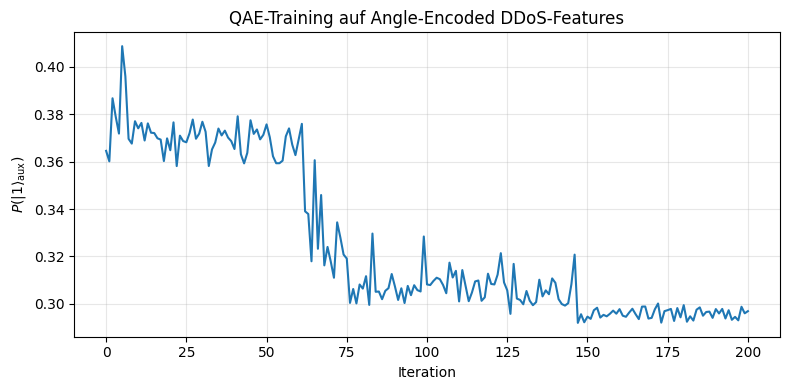

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel(r"$P(|1\rangle_{\mathrm{aux}})$")
plt.title("QAE-Training auf Angle-Encoded DDoS-Features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8 — Decoder & Rekonstruktion

Decoder $= U^\dagger(\theta^*)$.  Ablauf pro Flow:

1. Encode Flow als Angle-Encoded Product State $|\psi\rangle$.
2. Apply $U(\theta^*)$ → Information lebt in 4 Latent-Qubits.
3. **Reset** der 6 Trash-Qubits (= Bottleneck: nur Latent-Information bleibt).
4. Apply $U^\dagger(\theta^*)$ → rekonstruierter Zustand $\rho_{\text{out}}$.
5. Vergleiche $\rho_{\text{out}}$ mit $|\psi\rangle$ via `state_fidelity`.


In [11]:
def reconstruct(state_prep, encoder_params):
    """Encode + Reset Trash + Decode → 10-Qubit-Schaltkreis (gemischter Zustand)."""
    encoder = ansatz.assign_parameters(
        dict(zip(ansatz.parameters, encoder_params))
    )
    decoder = encoder.inverse()

    qc = QuantumCircuit(num_qubits)
    qc.compose(state_prep, inplace=True)
    qc.compose(encoder, inplace=True)

    for i in range(num_latent, num_qubits):
        qc.reset(i)

    qc.compose(decoder, inplace=True)
    return qc


fidelities = []
for sp in training_states:
    qc      = reconstruct(sp, optimal_params)
    rho_out = DensityMatrix(qc)
    psi_in  = Statevector(sp)
    fidelities.append(state_fidelity(rho_out, psi_in))

fidelities = np.array(fidelities)
print(f"Mittlere Fidelität: {fidelities.mean():.4f}")
print(f"Min:               {fidelities.min():.4f}")
print(f"Benign mean:       {fidelities[labels==0].mean():.4f}")
print(f"Attack mean:       {fidelities[labels==1].mean():.4f}")


Mittlere Fidelität: 0.3622
Min:               0.0000
Benign mean:       0.7135
Attack mean:       0.0109


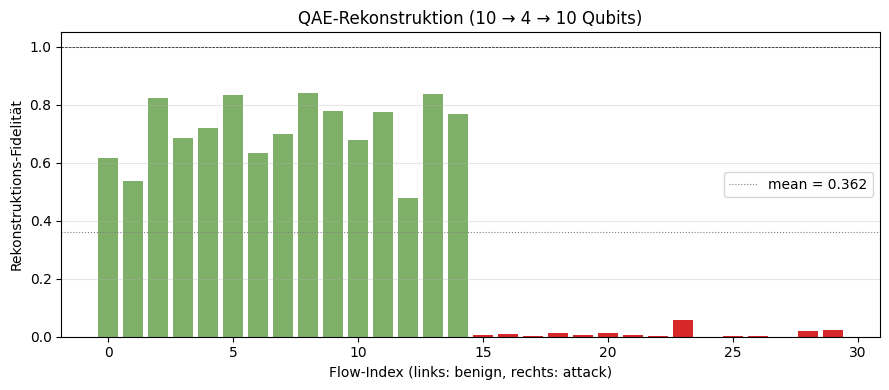

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#7fb069" if l == 0 else "#d62828" for l in labels]
ax.bar(range(len(fidelities)), fidelities, color=colors)
ax.axhline(1.0, color="k", lw=0.5, linestyle="--")
ax.axhline(fidelities.mean(), color="gray", lw=0.8, linestyle=":",
           label=f"mean = {fidelities.mean():.3f}")
ax.set_xlabel("Flow-Index (links: benign, rechts: attack)")
ax.set_ylabel("Rekonstruktions-Fidelität")
ax.set_title(f"QAE-Rekonstruktion ({num_qubits} → {num_latent} → {num_qubits} Qubits)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 9 — Rückgewinnung der Feature-Werte

Da das Decoding einen *gemischten* Zustand $\rho_{\text{out}}$ liefert, sind die rekonstruierten Winkel nicht mehr exakt durch `arctan2(<X>, <Z>)` gegeben — wir nutzen aber dieselbe Bloch-Vektor-Rekonstruktion wie in `angle_encoding_ddos.ipynb`, jetzt aus den reduzierten 1-Qubit-Dichtematrizen von $\rho_{\text{out}}$.

Bei perfekter Rekonstruktion stimmen die Werte mit den Original-Features überein.


In [13]:
_X = np.array([[0, 1], [1, 0]], dtype=complex)
_Z = np.array([[1, 0], [0, -1]], dtype=complex)


def angle_decode_density(rho, num_qubits, rotation="ry"):
    """Winkel-Decoding aus reduzierten 1-Qubit-Dichtematrizen."""
    angles = np.zeros(num_qubits)
    for i in range(num_qubits):
        rho_i = partial_trace(rho, [j for j in range(num_qubits) if j != i]).data
        ex = float(np.real(np.trace(rho_i @ _X)))
        ez = float(np.real(np.trace(rho_i @ _Z)))
        if rotation == "ry":
            angles[i] = np.arctan2(ex, ez)
        else:
            raise NotImplementedError("nur ry hier — siehe angle_encoding_ddos.ipynb")
    return angles


# Beispiel-Flow auswählen (z. B. erster Attack-Flow)
example_idx = np.where(labels == 1)[0][0]
example_state = training_states[example_idx]

qc_recon = reconstruct(example_state, optimal_params)
rho_out  = DensityMatrix(qc_recon)

angles_in    = training_angles[example_idx]
angles_recon = angle_decode_density(rho_out, num_qubits, rotation="ry")

raw_in    = flows[example_idx]
raw_recon = denormalize_features(angles_recon)

print(f"Beispiel-Flow: index={example_idx}, label={'attack' if labels[example_idx]==1 else 'benign'}")
print(f"\n{'Feature':28s} {'raw_in':>14s} {'raw_recon':>14s} {'theta_in':>9s} {'theta_recon':>12s}")
print("-" * 82)
for name, ri, rr, ai, ar in zip(FEATURE_NAMES, raw_in, raw_recon, angles_in, angles_recon):
    print(f"{name:28s} {ri:14.2f} {rr:14.2f} {ai:9.4f} {ar:12.4f}")


Beispiel-Flow: index=15, label=attack

Feature                              raw_in      raw_recon  theta_in  theta_recon
----------------------------------------------------------------------------------
Flow Duration (us)                 96034.13     9257733.10    0.0025       0.2424
Total Fwd Packets                   3705.43         501.10    1.1641       0.1574
Total Bwd Packets                     29.07       10000.00    0.0091      -0.1739
Fwd Packet Length Mean                52.71         333.49    0.1104       0.6985
Bwd Packet Length Mean                19.73         294.65    0.0413       0.6171
Flow Bytes/s                    72099123.92     5376979.58    2.2651       0.1689
Flow Packets/s                    516284.32     1000000.00    1.6220      -0.1287
Flow IAT Mean (us)                   124.57    10000000.00    0.0000      -0.1453
SYN Flag Count                        70.01           0.59    2.1996       0.0185
Packet Length Variance               351.88      124969.38

## 10 — Nächste Schritte

- **Echte Daten:** `flows = np.loadtxt(...)` aus CICDDoS2019, Rest unverändert. Robuste Statistik (z. B. p1/p99 statt min/max) für `FEATURE_RANGES` nehmen, sonst clippen Outlier wie in deinem Demo-Flow auf $\theta = \pi$.
- **Mehr Daten ≠ besser:** mit `n_benign + n_attack` skaliert die Trainingszeit linear pro COBYLA-Iteration. ~30–50 Flows reichen meist.
- **Latent-Klassifikation:** nach dem Training kannst du den Latent-Zustand (4 Qubits) als Embedding für Downstream-Klassifikation (DDoS/Benign) verwenden — z. B. via `Statevector` partial trace auf die Latent-Qubits, dann klassischer Klassifikator.
- **Hardware-Backend:** `StatevectorSampler` → `Sampler` aus `qiskit-ibm-runtime`.
- **Noise-aware:** `AerSimulator` mit `NoiseModel` (Pauli-Twirling, depolarizing, …) während des Trainings.
- **Gradientenbasiert:** `SamplerQNN` + `TorchConnector` → Adam statt COBYLA.
- **rx / rz-Encoding:** `angle_encode(..., rotation="rx")` und entsprechend in `angle_decode_density` anpassen — kann je nach Daten-Verteilung andere Trainings-Eigenschaften haben.
